In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv('../data/KDDTrain+.txt', names=columns).drop(columns=['difficulty'])
test  = pd.read_csv('../data/KDDTest+.txt',  names=columns).drop(columns=['difficulty'])

dos   = ['back','land','neptune','pod','smurf','teardrop']
probe = ['ipsweep','nmap','portsweep','satan']
r2l   = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster']
u2r   = ['buffer_overflow','loadmodule','perl','rootkit']

def map_label(label):
    if label == 'normal': return 'normal'
    if label in dos:      return 'DoS'
    if label in probe:    return 'Probe'
    if label in r2l:      return 'R2L'
    if label in u2r:      return 'U2R'
    return 'other'

train['label'] = train['label'].apply(map_label)
test['label']  = test['label'].apply(map_label)

train = train[train['label'] != 'other']
test  = test[test['label']  != 'other']

cat_cols = ['protocol_type', 'service', 'flag']
le_feat = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]])
    le_feat.fit(combined)
    train[col] = le_feat.transform(train[col])
    test[col]  = le_feat.transform(test[col])

le_label = LabelEncoder()
le_label.fit(pd.concat([train['label'], test['label']]))
train['label'] = le_label.transform(train['label'])
test['label']  = le_label.transform(test['label'])

class_names = list(le_label.classes_)
r2l_idx = class_names.index('R2L')
print("Classes:", class_names)
print("R2L index:", r2l_idx)

X_train = train.drop(columns=['label'])
y_train = train['label']
X_test  = test.drop(columns=['label'])
y_test  = test['label']
feature_names = list(X_train.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

# Baseline XGBoost for comparison
baseline_xgb = XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='mlogloss', n_jobs=-1)
baseline_xgb.fit(X_res, y_res)
baseline_preds = baseline_xgb.predict(X_test_scaled)

print("\n=== BASELINE XGBoost (R2L only) ===")
r2l_mask = y_test == r2l_idx
print(f"R2L Precision: {precision_score(y_test[r2l_mask], baseline_preds[r2l_mask], average='micro'):.3f}")
print(f"R2L Recall:    {recall_score(y_test == r2l_idx, baseline_preds == r2l_idx, average='binary'):.3f}")
print(f"R2L F1:        {f1_score(y_test == r2l_idx, baseline_preds == r2l_idx, average='binary'):.3f}")

Classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal']
R2L index: 2

=== BASELINE XGBoost (R2L only) ===
R2L Precision: 0.169
R2L Recall:    0.169
R2L F1:        0.288


In [2]:
# Give R2L a higher penalty for misclassification
# scale_pos_weight doesn't apply to multiclass — use sample_weight instead

from sklearn.utils.class_weight import compute_sample_weight

# Boost R2L weight by 10x during training
sample_weights = compute_sample_weight(class_weight='balanced', y=y_res)
r2l_in_res = (y_res == r2l_idx)
sample_weights[r2l_in_res] *= 10

xgb_weighted = XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='mlogloss', n_jobs=-1)
xgb_weighted.fit(X_res, y_res, sample_weight=sample_weights)
weighted_preds = xgb_weighted.predict(X_test_scaled)

print("=== Approach 1: Class Weights (R2L boosted 10x) ===")
print(classification_report(y_test, weighted_preds, target_names=class_names))

=== Approach 1: Class Weights (R2L boosted 10x) ===
              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      5741
       Probe       0.82      1.00      0.90      1106
         R2L       0.99      0.19      0.32      2199
         U2R       0.54      0.19      0.28        37
      normal       0.84      0.97      0.90      9711

    accuracy                           0.89     18794
   macro avg       0.83      0.67      0.68     18794
weighted avg       0.90      0.89      0.86     18794



 Threshold  R2L Recall  R2L Precision  Macro F1
      0.05    0.295589       0.984848  0.727089
      0.10    0.286494       0.987461  0.724819
      0.15    0.257844       0.989529  0.717262
      0.20    0.235562       0.988550  0.708482
      0.25    0.203274       0.986755  0.699196
      0.30    0.185084       0.985472  0.693758
      0.35    0.177353       0.984848  0.691400
      0.40    0.174170       0.987113  0.690454
      0.45    0.170532       0.989446  0.689343
      0.50    0.168713       0.989333  0.688777
      0.55    0.168713       0.989333  0.688777


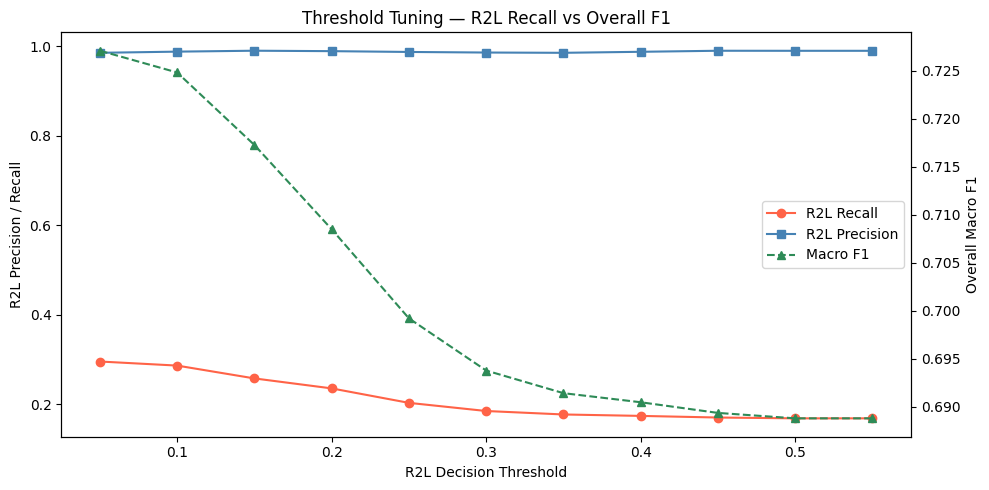

In [3]:
# Get probabilities for each class
proba = baseline_xgb.predict_proba(X_test_scaled)

# Baseline: argmax gives the predicted class
# Threshold tuning: lower the threshold needed to predict R2L
# Try different thresholds and track R2L recall vs overall F1

thresholds = np.arange(0.05, 0.60, 0.05)
results = []

for thresh in thresholds:
    preds_tuned = np.argmax(proba, axis=1).copy()
    # Override: if R2L probability exceeds threshold, predict R2L
    r2l_override = proba[:, r2l_idx] >= thresh
    preds_tuned[r2l_override] = r2l_idx

    r2l_recall    = recall_score(y_test == r2l_idx, preds_tuned == r2l_idx, average='binary')
    r2l_precision = precision_score(y_test == r2l_idx, preds_tuned == r2l_idx, average='binary', zero_division=0)
    macro_f1      = f1_score(y_test, preds_tuned, average='macro')
    results.append((round(thresh, 2), r2l_recall, r2l_precision, macro_f1))

results_df = pd.DataFrame(results, columns=['Threshold', 'R2L Recall', 'R2L Precision', 'Macro F1'])
print(results_df.to_string(index=False))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(results_df['Threshold'], results_df['R2L Recall'],    'tomato',   marker='o', label='R2L Recall')
ax1.plot(results_df['Threshold'], results_df['R2L Precision'], 'steelblue', marker='s', label='R2L Precision')
ax2.plot(results_df['Threshold'], results_df['Macro F1'],      'seagreen',  marker='^', label='Macro F1', linestyle='--')

ax1.set_xlabel('R2L Decision Threshold')
ax1.set_ylabel('R2L Precision / Recall')
ax2.set_ylabel('Overall Macro F1')
ax1.set_title('Threshold Tuning — R2L Recall vs Overall F1')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.savefig('../threshold_tuning.png', dpi=150)
plt.show()

In [4]:
# Train a separate model: R2L vs everything else
# Use original (non-SMOTE) scaled data — binary SMOTE applied separately

y_train_binary = (y_train == r2l_idx).astype(int)
y_test_binary  = (y_test  == r2l_idx).astype(int)

sm_binary = SMOTE(random_state=42)
X_res_b, y_res_b = sm_binary.fit_resample(X_train_scaled, y_train_binary)

print("Binary SMOTE — R2L vs rest:")
print(pd.Series(y_res_b).value_counts().to_dict())

xgb_r2l = XGBClassifier(n_estimators=200, random_state=42,
                         eval_metric='logloss', n_jobs=-1,
                         max_depth=6, learning_rate=0.05)
xgb_r2l.fit(X_res_b, y_res_b)

r2l_binary_preds = xgb_r2l.predict(X_test_scaled)

print("\n=== Approach 3: Dedicated R2L Binary Classifier ===")
print(classification_report(y_test_binary, r2l_binary_preds,
                             target_names=['Not R2L', 'R2L']))

Binary SMOTE — R2L vs rest:
{0: 124978, 1: 124978}

=== Approach 3: Dedicated R2L Binary Classifier ===
              precision    recall  f1-score   support

     Not R2L       0.90      1.00      0.95     16595
         R2L       0.99      0.17      0.30      2199

    accuracy                           0.90     18794
   macro avg       0.95      0.59      0.62     18794
weighted avg       0.91      0.90      0.87     18794



In [5]:
# Pick best threshold from approach 2
best_row    = results_df.loc[results_df['R2L Recall'].idxmax()]
best_thresh = best_row['Threshold']
proba       = baseline_xgb.predict_proba(X_test_scaled)
preds_tuned = np.argmax(proba, axis=1).copy()
preds_tuned[proba[:, r2l_idx] >= best_thresh] = r2l_idx

approaches = {
    'Baseline XGBoost':          baseline_preds,
    'Class Weights (10x)':       weighted_preds,
    f'Threshold ({best_thresh})': preds_tuned,
}

print(f"{'Approach':<30} {'R2L Recall':>12} {'R2L Precision':>15} {'Macro F1':>10}")
print('-' * 70)
for name, preds in approaches.items():
    rec  = recall_score(y_test == r2l_idx, preds == r2l_idx, average='binary')
    prec = precision_score(y_test == r2l_idx, preds == r2l_idx, average='binary', zero_division=0)
    mf1  = f1_score(y_test, preds, average='macro')
    print(f"{name:<30} {rec:>12.3f} {prec:>15.3f} {mf1:>10.3f}")

# Add dedicated binary classifier row separately
rec_b  = recall_score(y_test_binary, r2l_binary_preds)
prec_b = precision_score(y_test_binary, r2l_binary_preds, zero_division=0)
print(f"{'Dedicated R2L Classifier':<30} {rec_b:>12.3f} {prec_b:>15.3f} {'N/A':>10}")

Approach                         R2L Recall   R2L Precision   Macro F1
----------------------------------------------------------------------
Baseline XGBoost                      0.169           0.989      0.689
Class Weights (10x)                   0.188           0.988      0.678
Threshold (0.05)                      0.296           0.985      0.727
Dedicated R2L Classifier              0.174           0.992        N/A
